## Outlier Target Selection for HIGGS (MIA Paper §4.3)

Selection criterion from the paper:

> *"records that either have rare categorical attribute values or numerical values outside the attribute's 95% quantile"*

**Note for HIGGS**: This dataset typically contains only numerical variables. Rarity scoring is applied to numerical outliers (values > p95).

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ── Parameters (Choose Version) ────────────────
VERSION = "worst" # @param ["best", "middle", "worst"]

DATA_DIR_MAP = {
    "best":   "data/higgs/eff_rank_best",
    "middle": "data/higgs/eff_rank_middle",
    "worst":  "data/higgs/eff_rank_worst"
}
DATA_DIR = DATA_DIR_MAP[VERSION]

# N_ROWS          = 100000 # number of rows to load (HIGGS is 11M records total)
N_ROWS          = 11000000 # load all rows in HIGGS
QUANTILE        = 0.95   # percentile threshold for numerical outliers
EXCLUDE_COLS    = ["label"]   # columns excluded from scoring
N_TARGETS       = 5      # number of outlier records to select

# ── Data loading ───────────────────────────────
print(f"Loading {DATA_DIR} (Version: {VERSION})...")
df_raw = pd.read_csv(f"{DATA_DIR}.csv", nrows=N_ROWS)
df_raw["ID"] = [f"ID_{VERSION}_{i}" for i in range(len(df_raw))]
df = df_raw.set_index("ID")

# ── Column type classification ──────────────────
feat_cols = [c for c in df.columns if c not in EXCLUDE_COLS]
num_cols  = [c for c in feat_cols if pd.api.types.is_numeric_dtype(df[c])]
cat_cols  = [c for c in feat_cols if c not in num_cols]

print(f"Feature columns: {len(feat_cols)}")
print(f"  Numerical  : {num_cols}")
print(f"  Categorical: {cat_cols}")

Loading data/higgs/eff_rank_worst (Version: worst)...
Feature columns: 10
  Numerical  : ['jet1_pt', 'jet2_pt', 'jet3_pt', 'm_jj', 'm_jjj', 'm_lv', 'm_jlv', 'm_bb', 'm_wbb', 'm_wwbb']
  Categorical: []


### Step 1 — Numerical columns: scoring by 95th-percentile excess

- **Criterion**: value > p95
- **Score**: `(value − p95) / p95`  (relative excess; columns with p95 = 0 use `value / max`)

In [63]:
num_scores = pd.DataFrame(0.0, index=df.index, columns=num_cols)
num_thresholds = {}

for col in num_cols:
    p95 = df[col].quantile(QUANTILE)
    num_thresholds[col] = p95
    if p95 > 0:
        num_scores[col] = ((df[col] - p95) / p95).clip(lower=0)
    else:
        max_val = df[col].max()
        if max_val > 0:
            num_scores[col] = (df[col] / max_val).clip(lower=0)

# p95 threshold and number of records above it per column
summary = pd.DataFrame({
    "p95": num_thresholds,
    "# records above p95": (num_scores > 0).sum(),
    "max score": num_scores.max().round(3),
    "top record ID": num_scores.idxmax(),
}).rename_axis("column")

display(summary)

# Top 10 records by total score across all numerical columns
top_num = num_scores[num_scores.any(axis=1)].copy()
top_num["total score"] = top_num.sum(axis=1)
display(top_num.sort_values("total score", ascending=False).head(10).round(3))

,p95,# records above p95,max score,top record ID
column,,,,
jet1_pt,1.903232,549960,4.223,ID_worst_9747371
jet2_pt,1.908823,549896,5.102,ID_worst_209229
jet3_pt,1.890915,549885,6.779,ID_worst_7281078
m_jj,2.041707,549996,18.686,ID_worst_8947512
m_jjj,1.622115,549999,11.559,ID_worst_8947512
m_lv,1.359842,549997,4.878,ID_worst_2054418
m_jlv,1.713228,549999,7.325,ID_worst_3190879
m_bb,1.930621,549991,8.201,ID_worst_5402444
m_wbb,1.710341,549995,5.722,ID_worst_8947512


,jet1_pt,jet2_pt,jet3_pt,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb,total score
ID,,,,,,,,,,,
ID_worst_8947512,0.189,0.618,0.495,18.686,11.559,0.000,0.308,0.168,5.722,4.392,42.138
ID_worst_7017901,0.875,2.871,2.506,15.435,9.314,0.000,0.000,0.000,5.418,3.803,40.222
ID_worst_10617361,1.756,0.909,0.568,9.195,6.526,0.794,1.759,3.441,4.133,3.129,32.212
ID_worst_9328946,2.157,1.901,1.445,8.941,6.006,0.000,0.621,2.452,3.966,2.829,30.319
ID_worst_7822561,0.502,0.000,0.274,13.947,8.365,0.000,0.000,0.000,4.008,3.184,30.281
ID_worst_808741,0.280,0.069,0.000,14.221,8.640,0.000,0.000,0.000,4.133,2.832,30.176
ID_worst_5427867,0.013,0.000,0.000,13.436,8.202,0.347,0.000,0.000,4.043,3.177,29.218
ID_worst_5083948,0.914,0.107,0.802,12.699,7.970,0.000,0.000,0.000,3.891,2.728,29.111
ID_worst_1079872,0.015,0.089,0.270,13.457,8.222,0.107,0.000,0.000,4.070,2.855,29.083


### Step 2 — Combined score matrix

For HIGGS, we only have numerical scores. Records with at least one non-zero score are **outlier candidates**.

We normalize each column so that extreme outliers in any dimension are visible on the same scale.

In [64]:
scores_raw = num_scores[feat_cols] # cat_scores is empty in HIGGS

# Normalize each column to [0, 1] by dividing by its maximum score
col_max = scores_raw.max()
scores_norm = scores_raw.div(col_max.where(col_max > 0, 1.0))

# Tiebreaker: add a tiny fraction of the raw score
global_max = scores_raw.max().max()
scores = scores_norm + scores_raw * (1e-6 / global_max) if global_max > 0 else scores_norm

is_candidate = scores.gt(0).any(axis=1)
candidates = scores[is_candidate].copy()
candidates["total score"] = candidates[feat_cols].sum(axis=1)

print(f"Outlier candidates: {is_candidate.sum()} / {len(df)} records")

# Top 15 candidates (display with [0,1] normalized scores)
display(
    scores_norm[is_candidate]
    .assign(**{"total score": candidates["total score"]})
    .sort_values("total score", ascending=False)
    .head(15)
    .round(3)
    .style.background_gradient(cmap="YlOrRd", axis=0, subset=feat_cols)
)

Outlier candidates: 2841796 / 11000000 records


,jet1_pt,jet2_pt,jet3_pt,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb,total score
ID,,,,,,,,,,,
ID_worst_7017901,0.207000,0.563000,0.370000,0.826000,0.806000,0.000000,0.000000,0.000000,0.947000,0.866000,4.584000
ID_worst_8947512,0.045000,0.121000,0.073000,1.000000,1.000000,0.000000,0.042000,0.021000,1.000000,1.000000,4.302000
ID_worst_9747371,1.000000,0.621000,0.224000,0.087000,0.216000,0.000000,0.242000,0.420000,0.658000,0.627000,4.095000
ID_worst_10617361,0.416000,0.178000,0.084000,0.492000,0.565000,0.163000,0.240000,0.420000,0.722000,0.712000,3.992000
ID_worst_7281078,0.220000,0.306000,1.000000,0.108000,0.304000,0.000000,0.300000,0.454000,0.568000,0.674000,3.935000
ID_worst_9328946,0.511000,0.373000,0.213000,0.479000,0.520000,0.000000,0.085000,0.299000,0.693000,0.644000,3.816000
ID_worst_8156416,0.354000,0.860000,0.000000,0.000000,0.055000,0.000000,0.693000,0.614000,0.615000,0.567000,3.757000
ID_worst_109780,0.603000,0.672000,0.168000,0.000000,0.029000,0.000000,0.180000,0.746000,0.687000,0.607000,3.693000
ID_worst_6626343,0.756000,0.377000,0.544000,0.020000,0.193000,0.000000,0.234000,0.504000,0.460000,0.475000,3.562000


### Distribution of outlier scores

In [ ]:
# Distribution of outlier scores (candidates only)
cand_scores = scores_norm[is_candidate].copy()
cand_total = cand_scores[feat_cols].sum(axis=1)
cand_n_cols = cand_scores[feat_cols].gt(0).sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(cand_total, bins=50, edgecolor="black")
axes[0].set_xlabel("Total outlier score (sum of normalized scores)")
axes[0].set_ylabel("# records")
axes[0].set_title(f"Distribution of total outlier scores (n={len(cand_total):,})")

axes[1].hist(cand_n_cols, bins=range(1, cand_n_cols.max() + 2), edgecolor="black", align="left")
axes[1].set_xlabel("# outlier columns")
axes[1].set_ylabel("# records")
axes[1].set_title("# outlier columns per candidate")

plt.tight_layout()
plt.show()

### Step 3 — Column groups and per-group top candidates

Group HIGGS physics columns by theme (Lepton, Jets, Missing Energy, Invariant Mass) and pick the top-scoring record per group.

In [65]:
col_groups = {
    "lepton":         ["lepton_phi", "lepton_eta", "lepton_pt"],
    "missing_energy": ["missing_energy_phi", "missing_energy_magnitude"],
    "jets":           ["jet1_eta", "jet2_eta", "jet2_phi", "jet3_eta", "jet3_phi", "jet4_eta", "jet4_phi", 
                       "jet1_pt", "jet2_pt", "jet3_pt", "jet2_btag"],
    "invariant_mass": ["m_wwbb", "m_jj", "m_jjj", "m_lv", "m_jlv", "m_bb", "m_wbb"],
}

# Inspect the top-scoring record per group
remaining = scores[is_candidate].copy()

group_preview_rows = []
for group, cols in col_groups.items():
    valid_cols = [c for c in cols if c in remaining.columns]
    if not valid_cols: continue
    
    group_score = remaining[valid_cols].max(axis=1)
    if group_score.max() == 0: continue
    
    best_id = group_score.idxmax()
    best_score = group_score.max()
    best_col = remaining.loc[best_id, valid_cols].idxmax()
    best_val = df.loc[best_id, best_col]
    group_preview_rows.append({
        "group": group,
        "primary column": best_col,
        "candidate ID": best_id,
        "value": best_val,
        "score": round(best_score, 3),
    })

display(pd.DataFrame(group_preview_rows).set_index("group"))

,primary column,candidate ID,value,score
group,,,,
jets,jet3_pt,ID_worst_7281078,14.708989,1.0
invariant_mass,m_jj,ID_worst_8947512,40.192368,1.0


### Step 4 — Final selection: one record per group

Pick the top-scoring record from each valid group, ordered by rarity of outlier candidates in that group.

In [66]:
remaining = scores[is_candidate].copy()
selected_ids = []
result_rows  = []

def group_candidate_count(g):
    cols = [c for c in col_groups[g] if c in remaining.columns]
    if not cols: return 0
    return (remaining[cols] > 0).any(axis=1).sum()

valid_groups = [g for g in col_groups if any(c in remaining.columns for c in col_groups[g])]
sorted_groups = sorted(valid_groups, key=group_candidate_count)

for group in sorted_groups:
    if len(selected_ids) >= N_TARGETS:
        break
    valid_cols  = [c for c in col_groups[group] if c in remaining.columns]
    group_score = remaining[valid_cols].max(axis=1)
    if group_score.max() == 0:
        continue

    best_id  = group_score.idxmax()
    rec      = scores.loc[best_id]
    outlier_cols = rec[rec > 0].index.tolist()
    primary_col  = rec.idxmax()

    selected_ids.append(best_id)
    remaining = remaining.drop(best_id)  # remove selected record from pool

    result_rows.append({
        "group":           group,
        "selected ID":     best_id,
        "primary column":  primary_col,
        "value":           df.loc[best_id, primary_col],
        "norm. score":     round(rec[primary_col], 3),
        "outlier columns": ", ".join(outlier_cols),
    })

result_df = pd.DataFrame(result_rows).set_index("group")
display(result_df)

print("\nSelected IDs:", str(selected_ids).replace("'", '"'))

,selected ID,primary column,value,norm. score,outlier columns
group,,,,,
jets,ID_worst_7281078,jet3_pt,14.708989,1.0,"jet1_pt, jet2_pt, jet3_pt, m_jj, m_jjj, m_jlv,..."
invariant_mass,ID_worst_8947512,m_jj,40.192368,1.0,"jet1_pt, jet2_pt, jet3_pt, m_jj, m_jjj, m_jlv,..."



Selected IDs: ["ID_worst_7281078", "ID_worst_8947512"]


In [67]:
# Inspect the raw data of selected records
display(df.loc[selected_ids])

,jet1_pt,jet2_pt,jet3_pt,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb
ID,,,,,,,,,,
ID_worst_7281078,3.672900,4.893491,14.708989,6.159523,7.323238,0.970618,5.483646,9.125998,7.267241,6.149524
ID_worst_8947512,2.262515,3.089168,2.827855,40.192368,20.372782,0.987358,2.240671,2.255703,11.496522,8.374498


# Distribution of each column

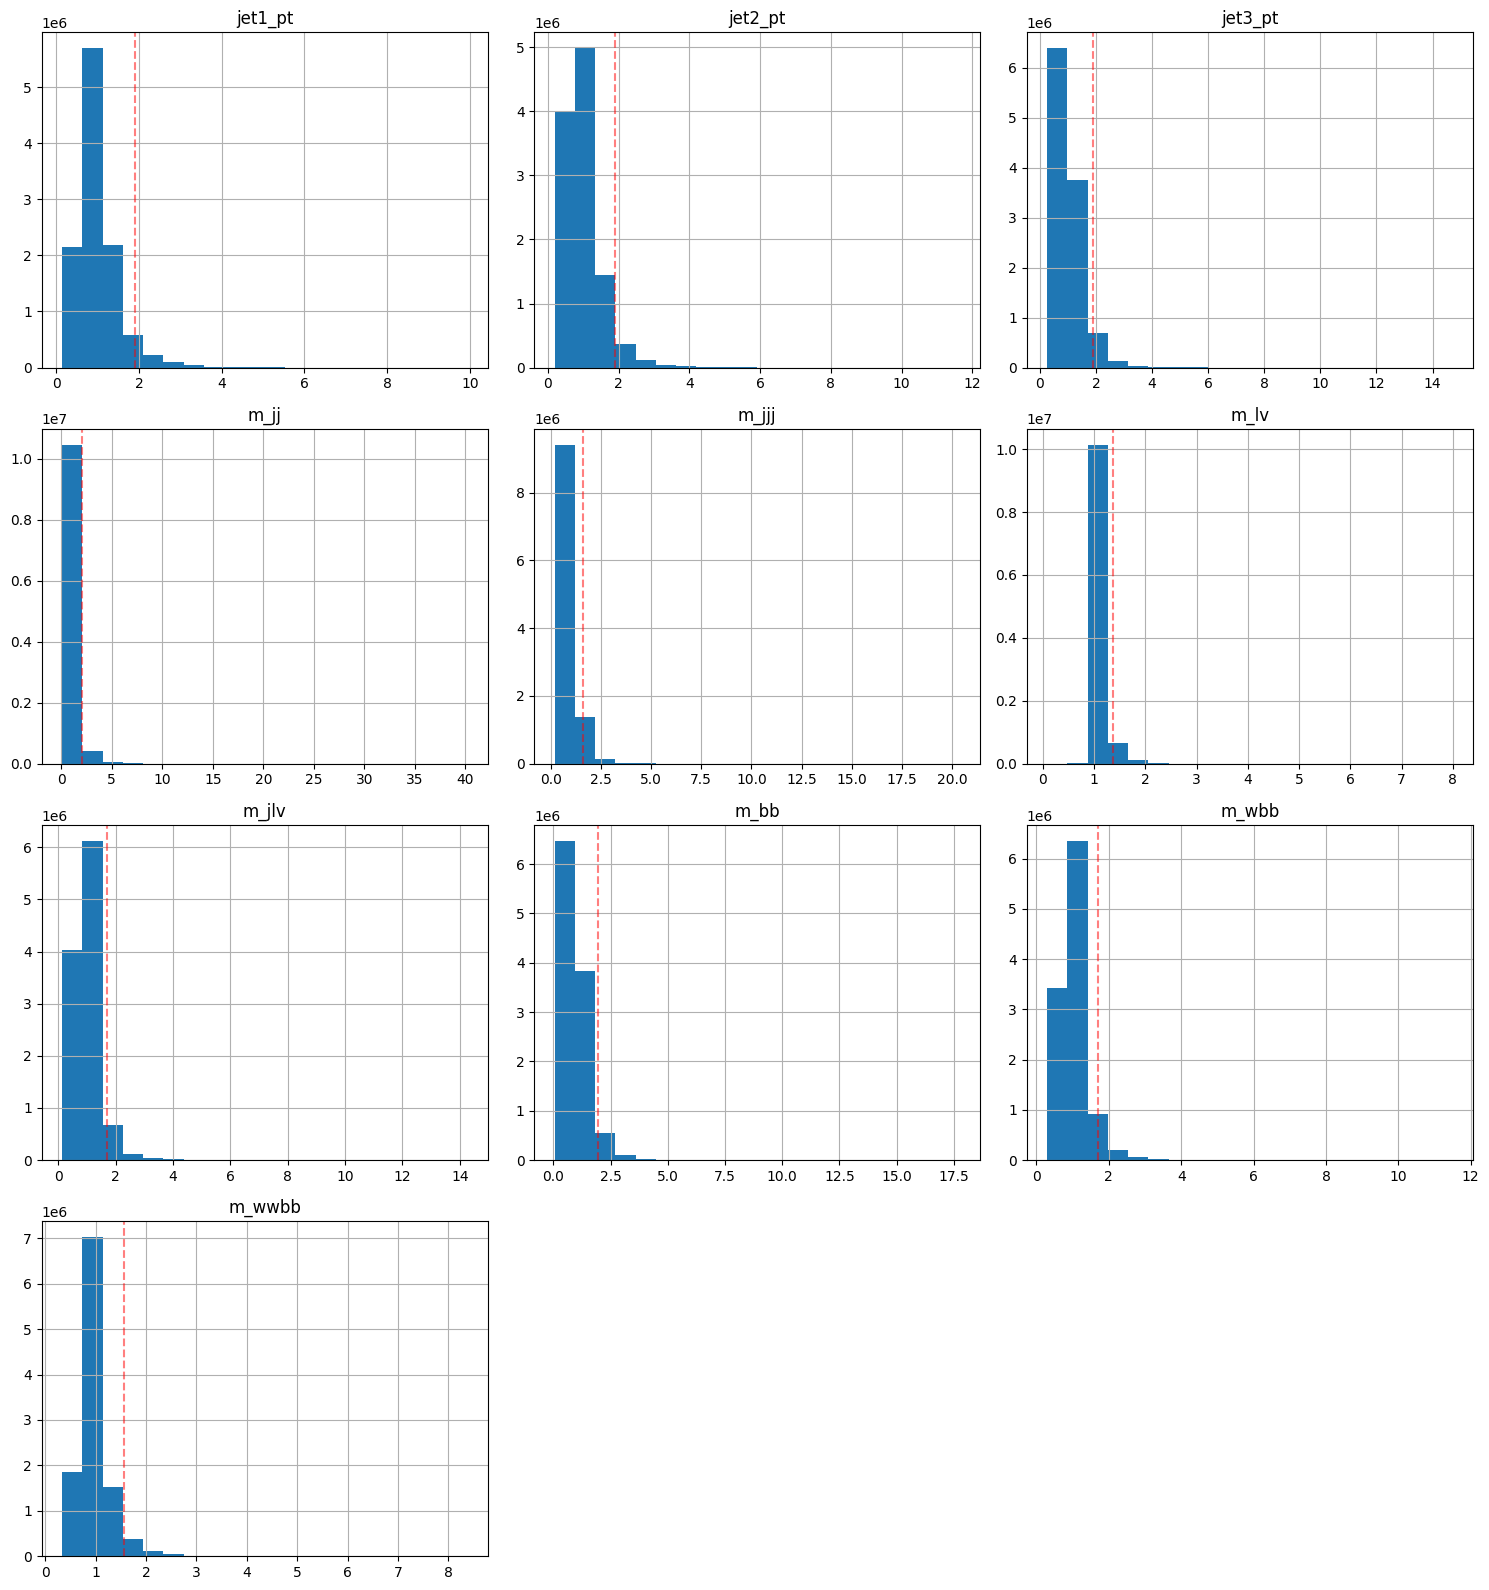

In [68]:
# Separate numeric columns (all in HIGGS subsets)
all_cols = num_cols
n = len(all_cols)

if n > 0:
    fig, axes = plt.subplots(
        nrows=(n + 2) // 3,
        ncols=3,
        figsize=(15, 4 * ((n + 2) // 3))
    )
    axes = axes.flatten()

    # Numeric columns → histogram
    for ax, col in zip(axes, all_cols):
        df[col].hist(bins=20, ax=ax)
        ax.set_title(col)
        # Mark p95 line
        p95 = df[col].quantile(QUANTILE)
        ax.axvline(p95, color='r', linestyle='--', alpha=0.5)

    # Hide unused subplots
    for ax in axes[n:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()